# Explore here

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

ds = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv", sep =",")

ds


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,60-69 y/o % of total pop,70-79,70-79 y/o % of total pop,80+,80+ y/o % of total pop,White-alone pop,% White-alone,Black-alone pop,% Black-alone,Native American/American Indian-alone pop,% NA/AI-alone,Asian-alone pop,% Asian-alone,Hawaiian/Pacific Islander-alone pop,% Hawaiian/PI-alone,Two or more races pop,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,...,Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,13.636445,7738,13.917016,5826,10.478229,4050,7.284042,2014,3.622237,42660,76.725239,10915,19.630942,267,0.480207,681,1.224798,62,0.111509,1016,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,...,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,10523,19.1,Autauga,Alabama,1,1,42438,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,12.539102,29986,13.753658,29932,13.728890,20936,9.602701,9368,4.296814,190301,87.285228,19492,8.940382,1684,0.772399,2508,1.150343,146,0.066966,3891,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,...,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,53519,26.3,Baldwin,Alabama,1,3,170912,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,12.354809,3278,13.174712,3076,12.362847,2244,9.018930,1048,4.212049,12209,49.069571,12042,48.398376,164,0.659137,113,0.454162,46,0.184880,307,1.233873,24881,-277,2820,10.4,12.9,-2.5,0.5,-9.1,-8.6,...,6.9,12.914231,2.723340,0.514126,11.631462,9.508784,32.283033,5,26201,6150,23.5,Barbour,Alabama,1,5,19689,57.5,55.6,59.1,11325,40.7,39.5,41.9,8013,11.0,10.1,11.8,2159,12.1,10.7,13.3,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,3038,13.562500,3115,13.906250,2545,11.361607,1723,7.691964,785,3.504464,17211,76.834821,4770,21.294643,98,0.437500,53,0.236607,26,0.116071,242,1.080357,22400,-155,2151,11.1,11.4,-0.3,0.4,-7.0,-6.6,...,6.9,11.626493,2.451783,0.462860,10.471635,8.560619,29.063942,0,22580,4773,21.1,Bibb,Alabama,1,7,17813,51.6,49.6,53.4,9190,38.7,37.4,40.2,6894,8.6,7.9,9.3,1533,10.0,8.8,11.3,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,7474,12.921853,7844,13.561549,6965,12.041840,4931,8.525242,2335,4.036999,55456,95.878285,950,1.642462,378,0.653527,185,0.319848,70,0.121024,801,1.384855,57840,13,489,11.8,11.4,0.3,0.1,-0.2,0.0,...,6.9,30.021267,6.330854,1.195171,27.039257,22.104740,75.047251,6,57667,13600,23.6,Blount,Alabama,1,

In [74]:
for col in ds.columns:
    print(col)

fips
TOT_POP
0-9
0-9 y/o % of total pop
19-Oct
10-19 y/o % of total pop
20-29
20-29 y/o % of total pop
30-39
30-39 y/o % of total pop
40-49
40-49 y/o % of total pop
50-59
50-59 y/o % of total pop
60-69
60-69 y/o % of total pop
70-79
70-79 y/o % of total pop
80+
80+ y/o % of total pop
White-alone pop
% White-alone
Black-alone pop
% Black-alone
Native American/American Indian-alone pop
% NA/AI-alone
Asian-alone pop
% Asian-alone
Hawaiian/Pacific Islander-alone pop
% Hawaiian/PI-alone
Two or more races pop
% Two or more races
POP_ESTIMATE_2018
N_POP_CHG_2018
GQ_ESTIMATES_2018
R_birth_2018
R_death_2018
R_NATURAL_INC_2018
R_INTERNATIONAL_MIG_2018
R_DOMESTIC_MIG_2018
R_NET_MIG_2018
Less than a high school diploma 2014-18
High school diploma only 2014-18
Some college or associate's degree 2014-18
Bachelor's degree or higher 2014-18
Percent of adults with less than a high school diploma 2014-18
Percent of adults with a high school diploma only 2014-18
Percent of adults completing some college 

In [ ]:
# Veo que columnas categoricas tengo
columnas_categoricas = ds.select_dtypes(include= ["object"]).columns

columnas_categoricas

C:\Users\trimb\AppData\Local\Temp\ipykernel_29208\4172201675.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = ds.select_dtypes(include= ["object"]).columns


Index(['COUNTY_NAME', 'STATE_NAME'], dtype='str')

In [ ]:
ds.info(verbose= True)

<class 'pandas.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Data columns (total 108 columns):
 #    Column                                                                         Dtype  
---   ------                                                                         -----  
 0    fips                                                                           int64  
 1    TOT_POP                                                                        int64  
 2    0-9                                                                            int64  
 3    0-9 y/o % of total pop                                                         float64
 4    19-Oct                                                                         int64  
 5    10-19 y/o % of total pop                                                       float64
 6    20-29                                                                          int64  
 7    20-29 y/o % of total pop                                    

In [ ]:
#Dropeo las columnas que no necesito
ds.drop(["0-9", "19-Oct", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+", "White-alone pop", "Black-alone pop", "Native American/American Indian-alone pop", "Asian-alone pop", "Hawaiian/Pacific Islander-alone pop", "Two or more races pop", "POP_ESTIMATE_2018", "N_POP_CHG_2018", "R_birth_2018", "R_death_2018", "R_INTERNATIONAL_MIG_2018", "R_DOMESTIC_MIG_2018", "Less than a high school diploma 2014-18", "High school diploma only 2014-18", "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18", "POVALL_2018", "PCTPOV017_2018", "PCTPOV517_2018", "CI90LBINC_2018", "CI90UBINC_2018", "Employed_2018", "Unemployed_2018", "Median_Household_Income_2018", "anycondition_Lower 95% CI", "anycondition_Upper 95% CI", "anycondition_number", "Obesity_Lower 95% CI", "Obesity_Upper 95% CI", "Obesity_number", "Heart disease_Lower 95% CI", "Heart disease_Upper 95% CI", "Heart disease_number", "COPD_Lower 95% CI", "COPD_Upper 95% CI", "COPD_number", "diabetes_Lower 95% CI", "diabetes_Upper 95% CI", "diabetes_number", "CKD_Lower 95% CI", "CKD_Upper 95% CI", "CKD_number", "Population Aged 60+", "Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)", "Active Primary Care Physicians per 100000 Population 2018 (AAMC)", "Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)", "Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)", "COUNTY_NAME"], axis = 1, inplace = True)

pd.set_option("display.max_columns", 83)

ds

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,% Black-alone,% NA/AI-alone,% Asian-alone,% Hawaiian/PI-alone,% Two or more races,GQ_ESTIMATES_2018,R_NATURAL_INC_2018,R_NET_MIG_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,PCTPOVALL_2018,MEDHHINC_2018,Civilian_labor_force_2018,Unemployment_rate_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Percent of Population Aged 60+,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,Obesity_prevalence,Heart disease_prevalence,COPD_prevalence,diabetes_prevalence,CKD_prevalence,Urban_rural_code
0,1001,55601,12.206615,13.735364,12.370281,12.749771,13.636445,13.917016,10.478229,7.284042,3.622237,76.725239,19.630942,0.480207,1.224798,0.111509,1.827305,455,2.2,0.6,11.3,32.6,28.4,27.7,13.8,59338,25957,3.6,119.0,217.1,7.6,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,19.1,Alabama,1,1,42438,47.6,35.8,7.9,8.6,12.9,3.1,3
1,1003,218022,11.355276,12.344167,10.814964,11.564429,12.539102,13.753658,13.728890,9.602701,4.296814,87.285228,8.940382,0.772399,1.150343,0.066966,1.784682,2190,0.1,24.8,9.7,27.6,31.3,31.3,9.8,57588,93849,3.6,115.5,217.1,7.6,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,26.3,Alabama,1,3,170912,40.2,29.7,7.8,8.6,12.0,3.2,4
2,1005,24881,10.980266,11.896628,13.134520,12.865239,12.354809,13.174712,12.362847,9.018930,4.212049,49.069571,48.398376,0.659137,0.454162,0.184880,1.233873,2820,-2.5,-8.6,27.0,35.7,25.1,12.2,30.9,34382,8373,5.2,68.9,217.1,7.6,12.914231,2.723340,0.514126,11.631462,9.508784,32.283033,5,26201,23.5,Alabama,1,5,19689,57.5,40.7,11.0,12.1,19.7,4.5,6
3,1007,22400,10.964286,11.589286,13.522321,13.897321,13.562500,13.906250,11.361607,7.691964,3.504464,76.834821,21.294643,0.437500,0.236607,0.116071,1.080357,2151,-0.3,-6.6,16.8,47.3,24.4,11.5,21.8,46064,8661,4.0,92.3,217.1,7.6,11.626493,2.451783,0.462860,10.471635,8.560619,29.063942,0,22580,21.1,Alabama,1,7,17813,51.6,38.7,8.6,10.0,14.1,3.3,2
4,1009,57840,12.266598,13.087828,11.656293,11.901798,12.921853,13.561549,12.041840,8.525242,4.036999,95.878285,1.642462,0.653527,0.319848,0.121024,1.384855,489,0.3,0.0,19.8,34.0,33.5,12.6,13.2,50412,25006,3.5,101.1,217.1,7.6,30.021267,6.330854,1.195171,27.039257,22.104740,75.047251,6,57667,23.6,Alabama,1,9,44448,46.3,34.0,9.2,10.5,13.5,3.4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,56037,43051,14.178532,14.694200,12.448027,15.277229,12.389956,12.220390,11.481731,5.105572,2.204362,93.835219,1.375113,1.544680,1.010429,0.157952,2.076607,660,5.6,-17.2,9.0,33.3,35.7,22.0,8.4,73315,21150,4.2,117.8,207.9,10.6,21.311749,11.997173,2.160982,9.836192,28.018244,40.537033,10,44527,15.8,Wyoming,56,37,31761,40.3,33.6,5.9,6.6,8.9,2.6,5
3136,56039,23081,10.328842,9.466661,12.854729,17.733200,14.830380,12.685759,12.456133,6.797799,2.846497,95.190850,0.758199,0.914172,1.412417,0.151640,1.572722,270,6.7,-14.5,5.6,13.2,23.8,57.4,6.3,99087,15340,3.0,159.2,207.9,10.6,11.425901,6.432063,1.158570,5.273493,15.021465,21.733183,6,22923,18.7,Wyoming,56,39,18842,24.3,19.4,5.2,4.9,7.2,2.4,5
3137,56041,20299,15.375142,

In [ ]:
#Label encoding de la columna categorica que me queda para hacer el mapa de correlacion
le = LabelEncoder()

ds_label_coded = ds.copy()

ds_label_coded[["STATE_NAME"]] = ds_label_coded[["STATE_NAME"]].apply(le.fit_transform)

ds_label_coded

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,80+ y/o % of total pop,% White-alone,% Black-alone,% NA/AI-alone,% Asian-alone,% Hawaiian/PI-alone,% Two or more races,GQ_ESTIMATES_2018,R_NATURAL_INC_2018,R_NET_MIG_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,PCTPOVALL_2018,MEDHHINC_2018,Civilian_labor_force_2018,Unemployment_rate_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Percent of Population Aged 60+,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,Obesity_prevalence,Heart disease_prevalence,COPD_prevalence,diabetes_prevalence,CKD_prevalence,Urban_rural_code
0,1001,55601,12.206615,13.735364,12.370281,12.749771,13.636445,13.917016,10.478229,7.284042,3.622237,76.725239,19.630942,0.480207,1.224798,0.111509,1.827305,455,2.2,0.6,11.3,32.6,28.4,27.7,13.8,59338,25957,3.6,119.0,217.1,7.6,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,19.1,0,1,1,42438,47.6,35.8,7.9,8.6,12.9,3.1,3
1,1003,218022,11.355276,12.344167,10.814964,11.564429,12.539102,13.753658,13.728890,9.602701,4.296814,87.285228,8.940382,0.772399,1.150343,0.066966,1.784682,2190,0.1,24.8,9.7,27.6,31.3,31.3,9.8,57588,93849,3.6,115.5,217.1,7.6,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,26.3,0,1,3,170912,40.2,29.7,7.8,8.6,12.0,3.2,4
2,1005,24881,10.980266,11.896628,13.134520,12.865239,12.354809,13.174712,12.362847,9.018930,4.212049,49.069571,48.398376,0.659137,0.454162,0.184880,1.233873,2820,-2.5,-8.6,27.0,35.7,25.1,12.2,30.9,34382,8373,5.2,68.9,217.1,7.6,12.914231,2.723340,0.514126,11.631462,9.508784,32.283033,5,26201,23.5,0,1,5,19689,57.5,40.7,11.0,12.1,19.7,4.5,6
3,1007,22400,10.964286,11.589286,13.522321,13.897321,13.562500,13.906250,11.361607,7.691964,3.504464,76.834821,21.294643,0.437500,0.236607,0.116071,1.080357,2151,-0.3,-6.6,16.8,47.3,24.4,11.5,21.8,46064,8661,4.0,92.3,217.1,7.6,11.626493,2.451783,0.462860,10.471635,8.560619,29.063942,0,22580,21.1,0,1,7,17813,51.6,38.7,8.6,10.0,14.1,3.3,2
4,1009,57840,12.266598,13.087828,11.656293,11.901798,12.921853,13.561549,12.041840,8.525242,4.036999,95.878285,1.642462,0.653527,0.319848,0.121024,1.384855,489,0.3,0.0,19.8,34.0,33.5,12.6,13.2,50412,25006,3.5,101.1,217.1,7.6,30.021267,6.330854,1.195171,27.039257,22.104740,75.047251,6,57667,23.6,0,1,9,44448,46.3,34.0,9.2,10.5,13.5,3.4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,56037,43051,14.178532,14.694200,12.448027,15.277229,12.389956,12.220390,11.481731,5.105572,2.204362,93.835219,1.375113,1.544680,1.010429,0.157952,2.076607,660,5.6,-17.2,9.0,33.3,35.7,22.0,8.4,73315,21150,4.2,117.8,207.9,10.6,21.311749,11.997173,2.160982,9.836192,28.018244,40.537033,10,44527,15.8,50,56,37,31761,40.3,33.6,5.9,6.6,8.9,2.6,5
3136,56039,23081,10.328842,9.466661,12.854729,17.733200,14.830380,12.685759,12.456133,6.797799,2.846497,95.190850,0.758199,0.914172,1.412417,0.151640,1.572722,270,6.7,-14.5,5.6,13.2,23.8,57.4,6.3,99087,15340,3.0,159.2,207.9,10.6,11.425901,6.432063,1.158570,5.273493,15.021465,21.733183,6,22923,18.7,50,56,39,18842,24.3,19.4,5.2,4.9,7.2,2.4,5
3137,56041,20299,15.375142,15.788955,10.606434,13.311001,11.773979,

In [ ]:
#Defino x e y porque voy a hacer el selectkbest antes para ver cuales son las columnas mas influyentes en el dataset

x = ds_label_coded.drop(['diabetes_prevalence'], axis = 1)
y = ds_label_coded["diabetes_prevalence"]

In [ ]:
#Ejecuto selectkbest

selector = SelectKBest(score_func=f_regression, k=20)
X_new = selector.fit_transform(x, y)

print("Forma original:", x.shape)
print("Forma reducida:", X_new.shape)

Forma original: (3140, 50)
Forma reducida: (3140, 20)


In [82]:
# Obtengo una máscara True/False indicando qué columnas fueron seleccionadas
mask = selector.get_support()

# Extraemos los nombres de las columnas seleccionadas
selected_cols = np.array(ds_label_coded.columns.drop(['diabetes_prevalence']))[mask]

selected_cols

array(['30-39 y/o % of total pop', '70-79 y/o % of total pop',
       '% White-alone', '% Black-alone', '% Asian-alone',
       'R_NATURAL_INC_2018',
       'Percent of adults with less than a high school diploma 2014-18',
       'Percent of adults with a high school diploma only 2014-18',
       "Percent of adults with a bachelor's degree or higher 2014-18",
       'PCTPOVALL_2018', 'MEDHHINC_2018', 'Unemployment_rate_2018',
       'Med_HH_Income_Percent_of_State_Total_2018',
       'Active Physicians per 100000 Population 2018 (AAMC)',
       'anycondition_prevalence', 'Obesity_prevalence',
       'Heart disease_prevalence', 'COPD_prevalence', 'CKD_prevalence',
       'Urban_rural_code'], dtype=object)

In [ ]:
#Dataset definitivo para modelar agregando la variable objetivo

ds_limpio = ds_label_coded[selected_cols]

ds_limpio["diabetes_prevalence"] = y

ds_limpio

,30-39 y/o % of total pop,70-79 y/o % of total pop,% White-alone,% Black-alone,% Asian-alone,R_NATURAL_INC_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,PCTPOVALL_2018,MEDHHINC_2018,Unemployment_rate_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),anycondition_prevalence,Obesity_prevalence,Heart disease_prevalence,COPD_prevalence,CKD_prevalence,Urban_rural_code,diabetes_prevalence
0,12.749771,7.284042,76.725239,19.630942,1.224798,2.2,11.3,32.6,27.7,13.8,59338,3.6,119.0,217.1,47.6,35.8,7.9,8.6,3.1,3,12.9
1,11.564429,9.602701,87.285228,8.940382,1.150343,0.1,9.7,27.6,31.3,9.8,57588,3.6,115.5,217.1,40.2,29.7,7.8,8.6,3.2,4,12.0
2,12.865239,9.018930,49.069571,48.398376,0.454162,-2.5,27.0,35.7,12.2,30.9,34382,5.2,68.9,217.1,57.5,40.7,11.0,12.1,4.5,6,19.7
3,13.897321,7.691964,76.834821,21.294643,0.236607,-0.3,16.8,47.3,11.5,21.8,46064,4.0,92.3,217.1,51.6,38.7,8.6,10.0,3.3,2,14.1
4,11.901798,8.525242,95.878285,1.642462,0.319848,0.3,19.8,34.0,12.6,13.2,50412,3.5,101.1,217.1,46.3,34.0,9.2,10.5,3.4,2,13.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3135,15.277229,5.105572,93.835219,1.375113,1.010429,5.6,9.0,33.3,22.0,8.4,73315,4.2,117.8,207.9,40.3,33.6,5.9,6.6,2.6,5,8.9
3136,17.733200,6.797799,95.190850,0.758199,1.412417,6.7,5.6,13.2,57.4,6.3,99087,3.0,159.2,207.9,24.3,19.4,5.2,4.9,2.4,5,7.2
3137,13.311001,6.074191,95.354451,0.827627,0.472930,6.3,7.2,40.1,15.4,10.0,63401,4.4,101.8,207.9,42.2,34.2,7.2,8.0,3.0,5,10.4
3138,11.452124,9.397590,94.483196,0.507292,0.824350,-1.4,10.4,30.3,21.5,11.9,55190,4.2,88.6,207.9,37.5,28.4,8.2,8.3,3.4,6,11.3


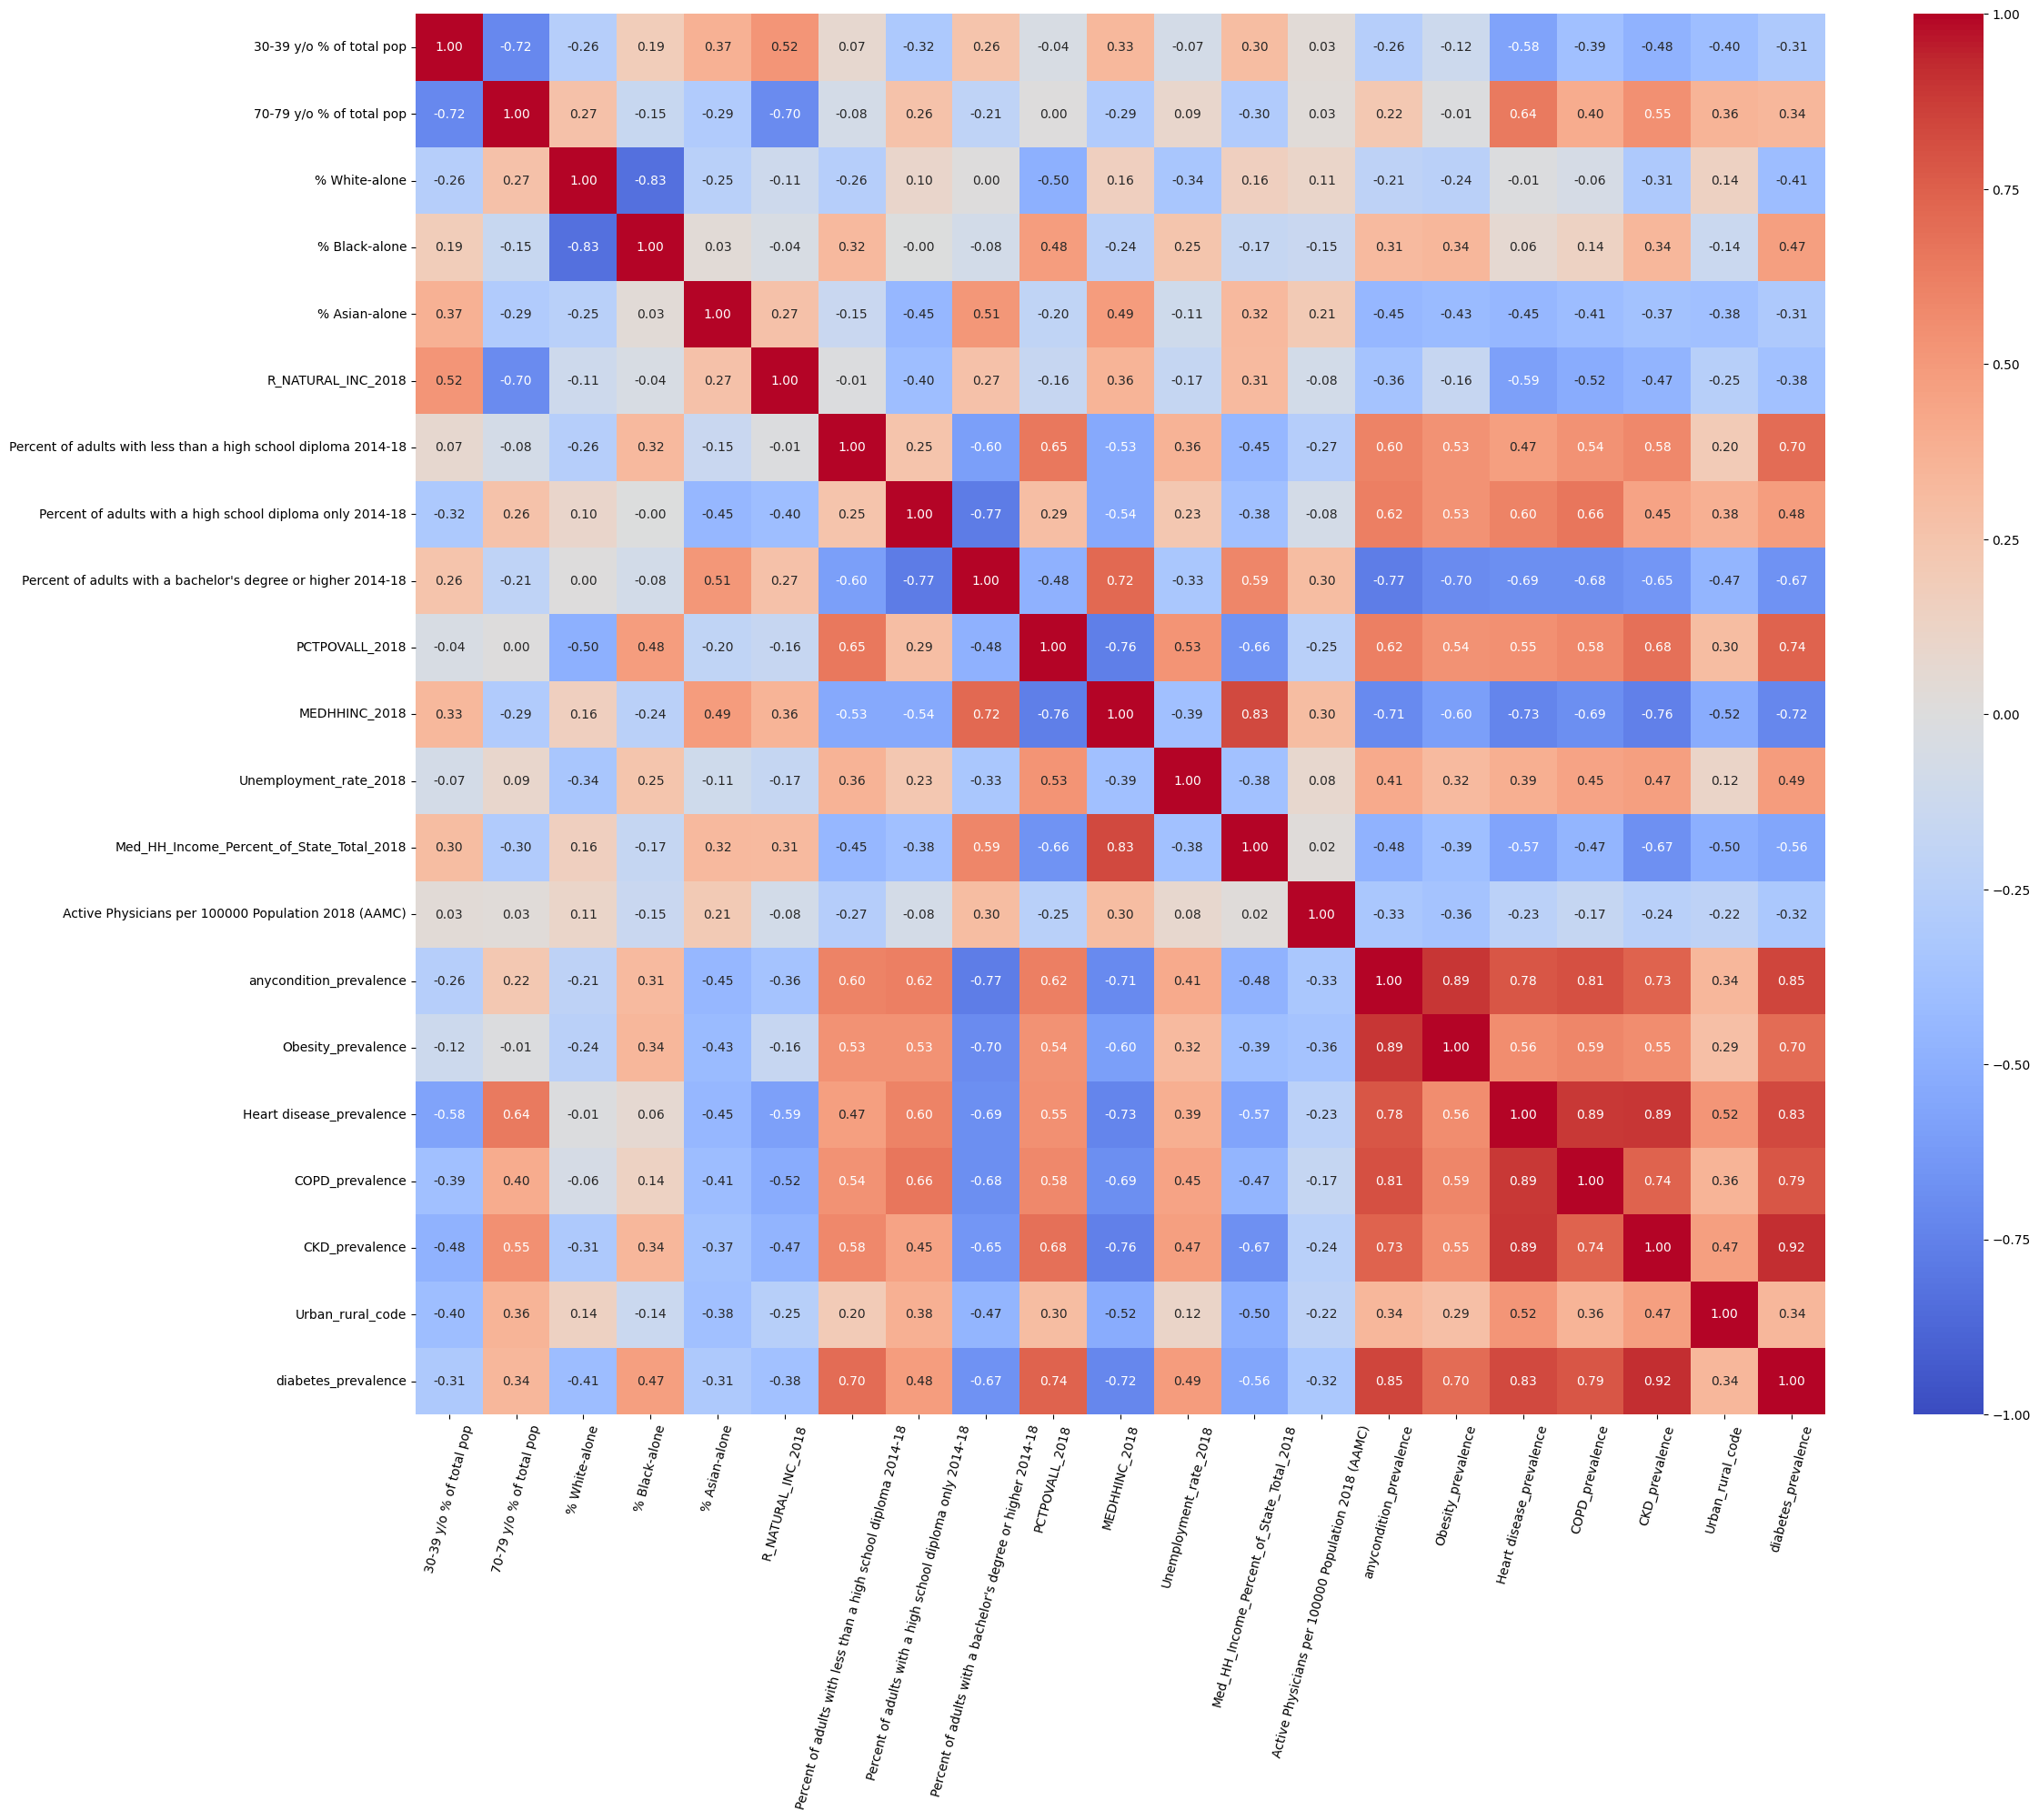

In [ ]:
#Heatmap de correlacion
corr = ds_limpio.corr()

plt.figure(figsize=(25, 20))


sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.tick_params(axis = "x", rotation = 75)
plt.show()

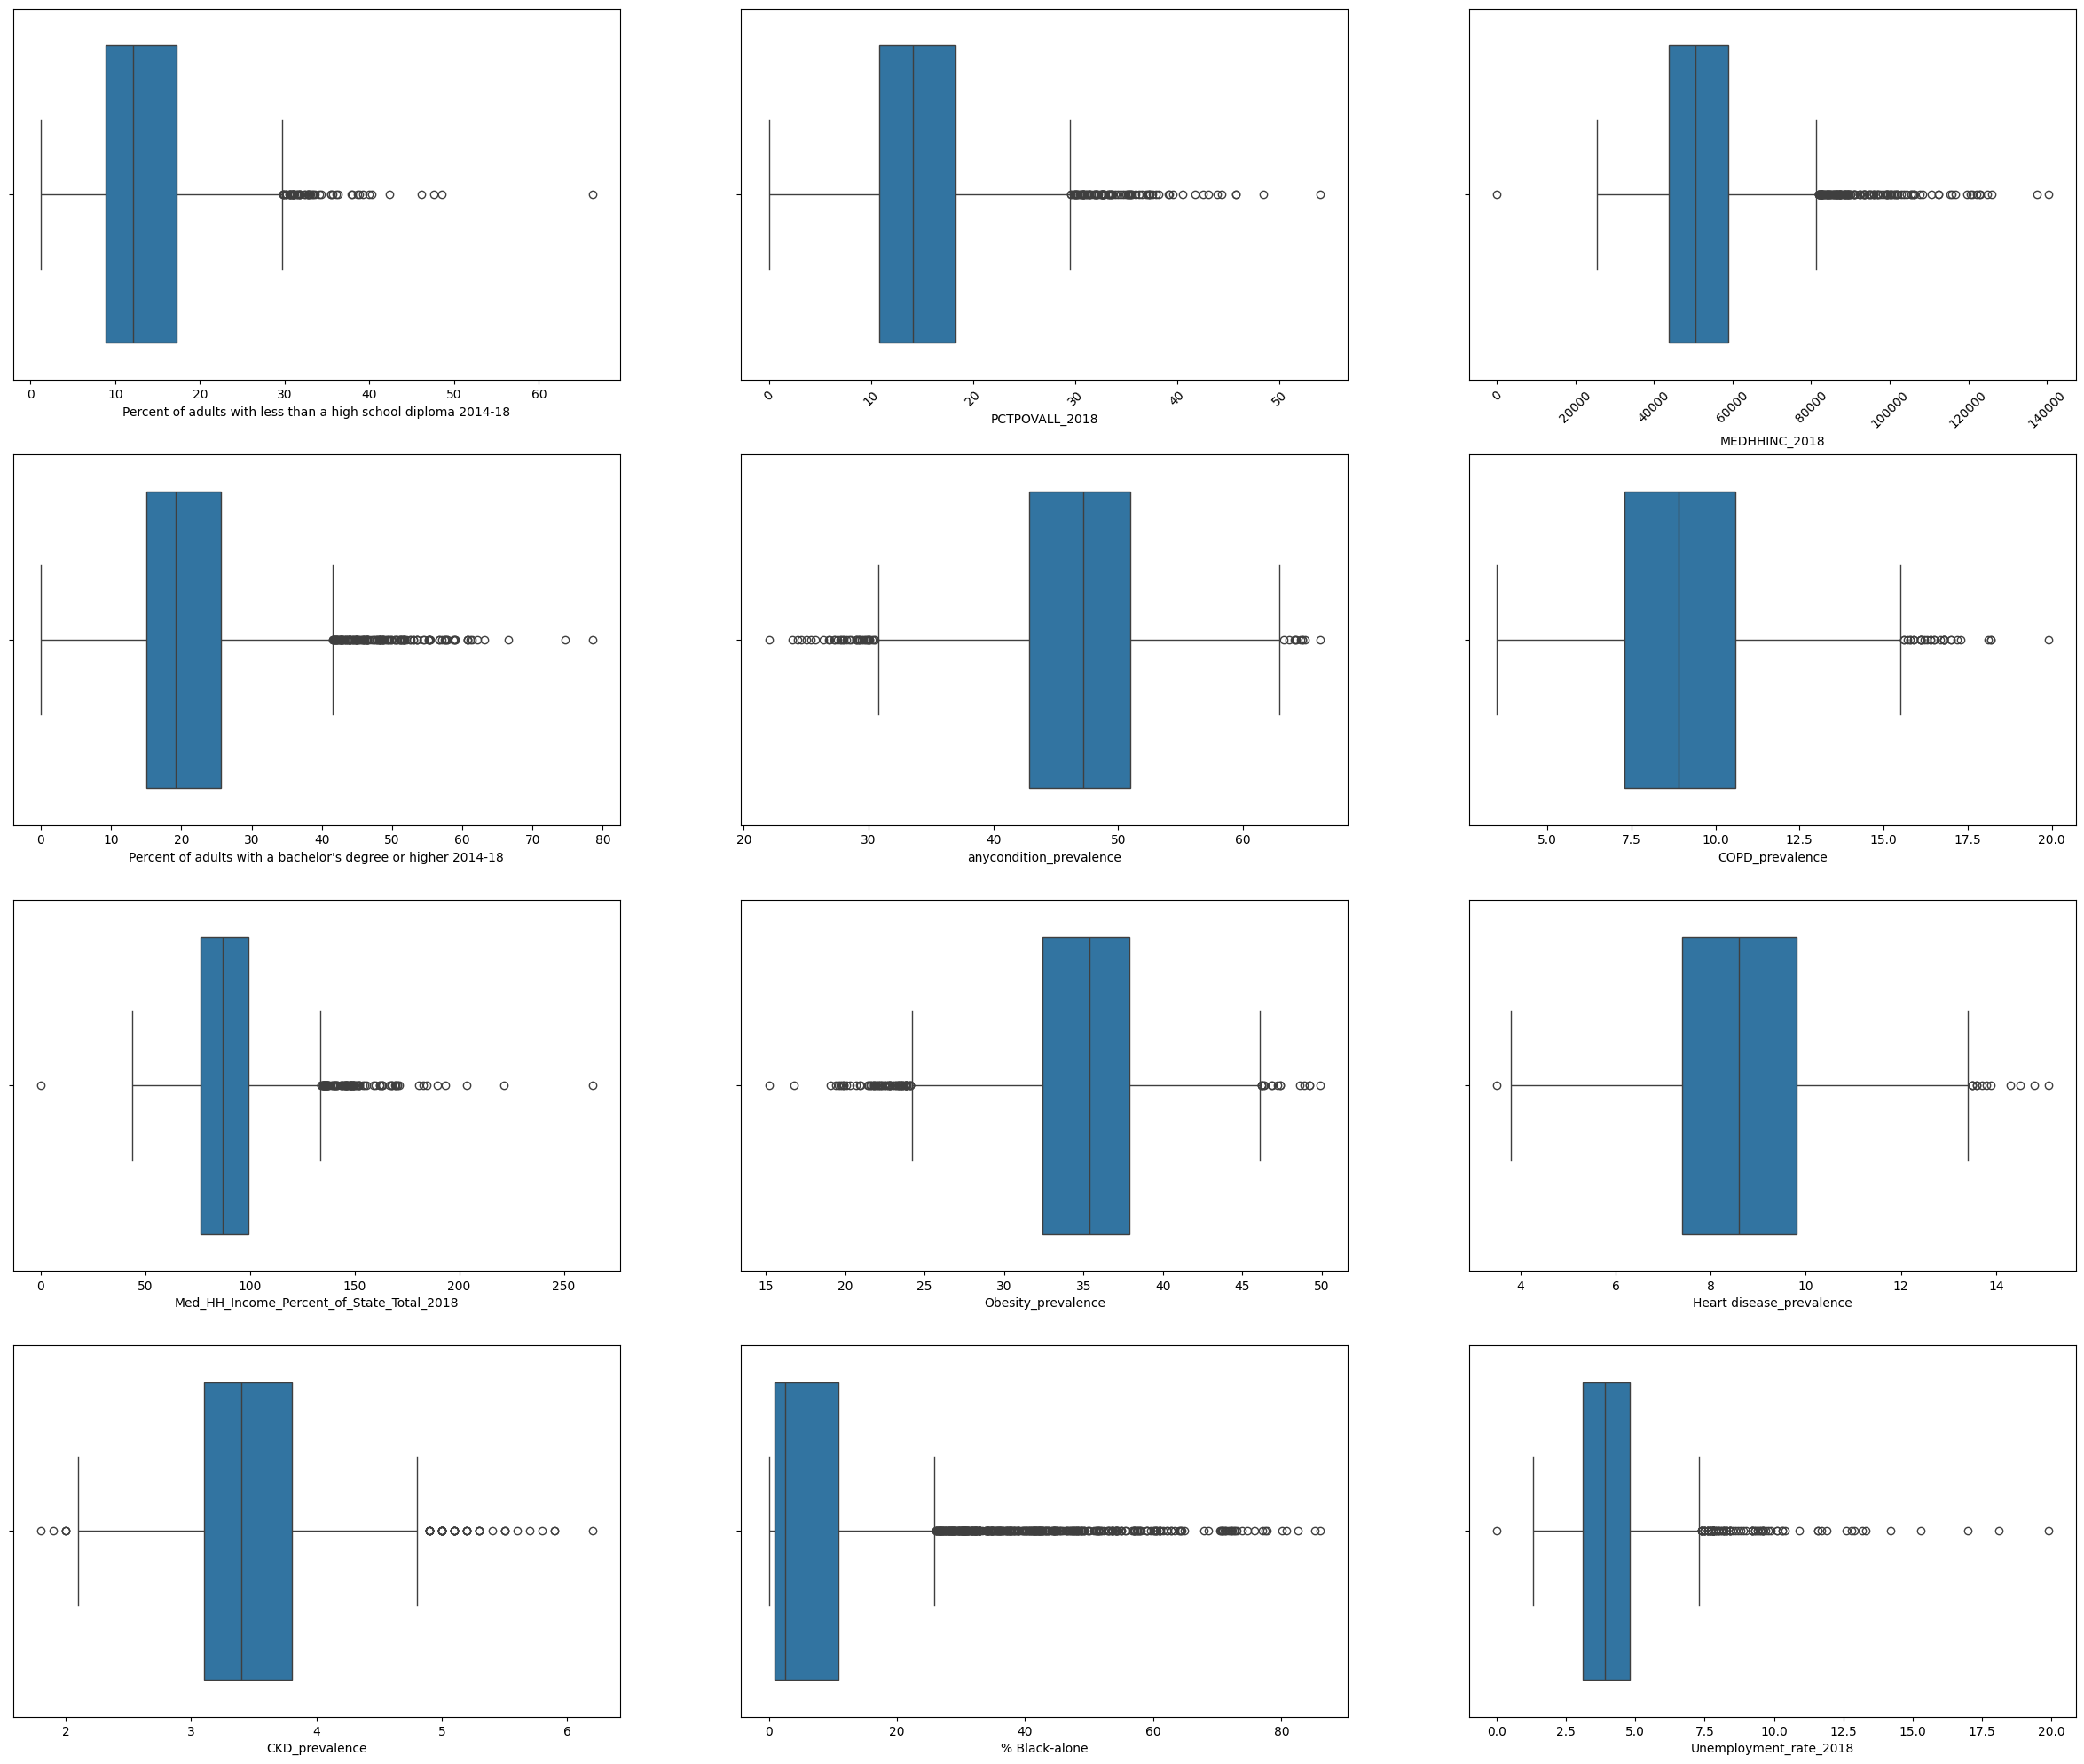

In [ ]:
# Grafico, no elimino outliers porque tengo muy pocos datos y al ser datos socio demograficos son utiles en su totalidad

fig, axis  = plt.subplots(4, 3, figsize = (30,25))

sns.boxplot(ax = axis [0, 0], data = ds_limpio, x = "Percent of adults with less than a high school diploma 2014-18")
sns.boxplot(ax = axis [1, 0], data = ds_limpio, x = "Percent of adults with a bachelor's degree or higher 2014-18")
sns.boxplot(ax = axis [0, 1], data = ds_limpio, x = "PCTPOVALL_2018")
sns.boxplot(ax = axis [0, 2], data = ds_limpio, x = "MEDHHINC_2018")
sns.boxplot(ax = axis [2, 0], data = ds_limpio, x = "Med_HH_Income_Percent_of_State_Total_2018")
sns.boxplot(ax = axis [1, 1], data = ds_limpio, x = "anycondition_prevalence")
sns.boxplot(ax = axis [2, 1], data = ds_limpio, x = "Obesity_prevalence")
sns.boxplot(ax = axis [2, 2], data = ds_limpio, x = "Heart disease_prevalence")
sns.boxplot(ax = axis [1, 2], data = ds_limpio, x = "COPD_prevalence")
sns.boxplot(ax = axis [3, 0], data = ds_limpio, x = "CKD_prevalence")
sns.boxplot(ax = axis [3, 1], data = ds_limpio, x = "% Black-alone")
sns.boxplot(ax = axis [3, 2], data = ds_limpio, x = "Unemployment_rate_2018")

axis[0, 1].tick_params(axis = "x", rotation = 45)
axis[0, 2].tick_params(axis = "x", rotation = 45)

plt.show()

In [86]:
# Preparo todos los datos para el modelo

x = ds_limpio.drop(["diabetes_prevalence"], axis = 1)
y = ds_limpio["diabetes_prevalence"]


X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42
)

In [ ]:
#En este caso hice el modelo dentro del pipe para probar una forma distinta de como ejecutarlo

pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
    ])

In [ ]:
# Entreno
pipe.fit(X_train, y_train)

# Predigo
y_pred = pipe.predict(X_test)

In [89]:
y_pred

array([14.78395739,  9.71922591, 19.02093089, 10.8200296 ,  8.92722602,
        9.9973023 , 11.08928105, 17.21873092, 11.38943237,  9.06624816,
       11.89074268, 16.02961801,  8.97438152, 15.31010867, 10.31810103,
       13.15409039, 12.67989112, 14.48677198, 18.03989396, 12.00676688,
       14.95370606, 12.42606338, 10.82962326, 15.28388147, 12.27307022,
       10.39459137,  7.60216372, 12.53132987, 11.12338676, 16.80870353,
       20.00465565, 17.5821455 , 14.07179305, 12.52940498, 10.872551  ,
       15.61392526, 14.552037  , 10.38077069, 12.63789267,  8.80090353,
       17.75487412, 10.12618691, 11.64264408, 12.16278653, 11.46942047,
       14.83495015, 13.30497484, 13.787437  , 16.563896  , 17.63640069,
       15.37251568, 23.51219385, 10.34746478, 15.82385583, 13.87615558,
       19.81516598, 10.6583509 , 10.68550993, 12.90045193, 12.63749611,
        8.85118067, 14.62817029, 14.3701868 , 10.44311784, 12.54036886,
       10.16324805, 11.82319844, 13.67717599, 12.20860705, 12.02

In [90]:
print(f"Error cuadrático medio: {mean_squared_error(y_test, y_pred)}")
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred)}")

Error cuadrático medio: 0.3230192234332918
Coeficiente de determinación: 0.9598392240624403


In [91]:
#Aplico Lasso

lasso_model = Lasso(alpha = 0.1, max_iter = 300)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

y_pred_lasso

array([14.86392994,  9.97006024, 18.80731329, 10.63888364,  9.18023892,
       10.26979355, 11.20172871, 17.02089155, 11.74325083,  9.78974869,
       11.85173823, 16.53998633,  9.31267283, 15.53819339, 10.39572696,
       13.19594335, 12.69151538, 14.45897964, 18.03371632, 11.63428534,
       15.49293402, 12.70884178, 10.8434582 , 15.3429293 , 11.84901528,
       10.06822851,  7.27489411, 12.25923677, 10.98636876, 16.94276928,
       19.33759529, 18.33779712, 14.04519355, 12.23701326, 10.37393204,
       15.47410677, 14.85210785, 10.31390934, 12.96786831,  8.96739935,
       18.06354882, 10.48950491, 11.37271991, 12.30204868, 11.0681413 ,
       14.61600706, 13.04049637, 14.06784481, 16.33187563, 17.57074557,
       15.23948212, 21.47418407, 10.30390866, 15.17536193, 14.02546743,
       19.95646453, 10.98503758, 10.74507828, 12.75983955, 12.23191381,
        8.94285388, 15.12279922, 14.0299914 ,  9.94194043, 12.36928102,
       10.6039298 , 12.07152337, 13.52551957, 12.63075346, 12.07

In [92]:
#Error y coeficiente de Lasso

print(f"Error cuadrático medio: {mean_squared_error(y_test, y_pred_lasso)}")
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred_lasso)}")

Error cuadrático medio: 0.5162385875858931
Coeficiente de determinación: 0.9358163826103032


In [ ]:
#Aplico Ridge, se que el ejercicio no lo pide pero no quice dejar de hacerlo

ridge_model = Ridge(alpha = 0.1, max_iter = 300)

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

y_pred_ridge

array([14.78379276,  9.71994105, 19.02081981, 10.81923592,  8.92785862,
        9.99814758, 11.08936536, 17.21837028, 11.39036033,  9.06877978,
       11.89068704, 16.03137693,  8.9752638 , 15.31030199, 10.31833636,
       13.15418145, 12.67996289, 14.48711347, 18.03979862, 12.00604324,
       14.95447263, 12.42629621, 10.82955804, 15.2836054 , 12.27237283,
       10.39390487,  7.60138014, 12.53101134, 11.12285665, 16.80819357,
       20.00340347, 17.58403274, 14.07138935, 12.52857128, 10.87188345,
       15.61346985, 14.5533952 , 10.38102799, 12.63825976,  8.8010653 ,
       17.75563773, 10.12642306, 11.64175825, 12.16283209, 11.46885107,
       14.83508716, 13.30397562, 13.7886066 , 16.56331302, 17.6379892 ,
       15.3725942 , 23.50793525, 10.34711943, 15.82272769, 13.87701392,
       19.81562838, 10.65937414, 10.68517338, 12.89965589, 12.63674922,
        8.85182823, 14.62973683, 14.36958194, 10.44193768, 12.5397962 ,
       10.1641859 , 11.82335158, 13.67701938, 12.20892137, 12.02

In [94]:
#Error y coeficiente de Ridge

print(f"Error cuadrático medio: {mean_squared_error(y_test, y_pred_ridge)}")
print(f"Coeficiente de determinación: {r2_score(y_test, y_pred_ridge)}")

Error cuadrático medio: 0.32306472307999246
Coeficiente de determinación: 0.9598335671201166


In [98]:
#Ejecuto el bucle para que itere sobre lasso modificando el alfa en ascenso y viendo como se comporta

resultado = []
alphas = []

for alpha in np.arange (0.1, 20.1 , 0.5):
    lasso_model = Lasso(alpha = alpha, max_iter = 300)
    lasso_model.fit(X_train, y_train)
    y_pred_lasso = lasso_model.predict(X_test)
    resultado.append(r2_score(y_test, y_pred_lasso))
    alphas.append(alpha)

    
resultado

[0.9358163826103032,
 0.8872557068619744,
 0.8359090020901004,
 0.808234488939632,
 0.7930310208230752,
 0.7736724718788982,
 0.7501609631879517,
 0.7224961561873627,
 0.6915035432726409,
 0.6629160449360872,
 0.6311584161397219,
 0.6079292794670823,
 0.6026019687363223,
 0.5968889854032049,
 0.5907899737479092,
 0.5843049706224974,
 0.5774338767004173,
 0.5710720863293925,
 0.5651696123445263,
 0.5589688468969097,
 0.5524694908299148,
 0.5456717763389829,
 0.5385757256116084,
 0.5311812823476229,
 0.5241317634219073,
 0.517722033997614,
 0.5177208950804668,
 0.5177197558528933,
 0.5177186163148937,
 0.5177174764664677,
 0.5177163363076158,
 0.5177151958383372,
 0.5177140550586328,
 0.5177129139685019,
 0.5177117725679448,
 0.5177106308569616,
 0.517709488835552,
 0.5177083465037162,
 0.5177072038614541,
 0.5177060609087659]

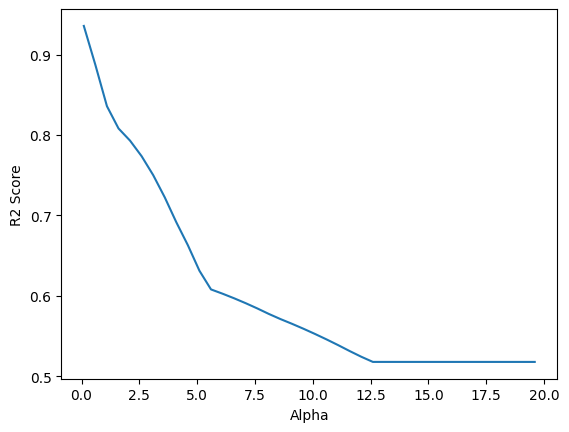

In [99]:
plt.plot(alphas, resultado)
plt.xlabel("Alpha")
plt.ylabel("R2 Score")
plt.show()

Conclusion: El modelo me dio un R2 de 0.95, lo que significa que el modelo explica el 95% de la variabilidad de la prevalencia de diabetes, un resultado muy bueno que no necesita optimización. Al probar con Lasso y subir el alpha, el R² baja progresivamente, lo que muestra que cuanta más regularización le aplicamos al modelo, peor predice en este caso.